In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits import mplot3d

In [2]:
df = pd.read_excel('Dataset Pengaruh TPT dan RLS terhadap presentase penduduk miskin.xlsx')
df

,Provinsi,Persentase Penduduk Miskin (Persen),Tingkat Pengangguran Terbuka (Persen),Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas
0,ACEH,12.64,5.75,9.95
1,SUMATERA UTARA,7.19,5.60,10.18
2,SUMATERA BARAT,5.42,5.75,9.72
3,RIAU,6.36,3.70,9.69
4,JAMBI,7.26,4.48,9.26
5,SUMATERA SELATAN,10.51,3.86,8.98
6,BENGKULU,12.52,3.11,9.40
7,LAMPUNG,10.62,4.19,8.80
8,KEP. BANGKA BELITUNG,5.08,4.63,8.78
9,KEP. RIAU,4.78,6.39,10.65


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Provinsi                                               38 non-null     str    
 1   Persentase Penduduk Miskin (Persen)                    38 non-null     float64
 2   Tingkat Pengangguran Terbuka (Persen)                  38 non-null     float64
 3   Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas  38 non-null     float64
dtypes: float64(3), str(1)
memory usage: 1.3 KB


In [4]:
print("=== JUMLAH MISSING VALUE PER KOLOM ===")
print(df.isnull().sum())

=== JUMLAH MISSING VALUE PER KOLOM ===
Provinsi                                                 0
Persentase Penduduk Miskin (Persen)                      0
Tingkat Pengangguran Terbuka (Persen)                    0
Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas    0
dtype: int64


In [5]:
X = df[['Tingkat Pengangguran Terbuka (Persen)', 'Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas']]
X.head()

,Tingkat Pengangguran Terbuka (Persen),Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas
0,5.75,9.95
1,5.60,10.18
2,5.75,9.72
3,3.70,9.69
4,4.48,9.26


In [6]:
y = df['Persentase Penduduk Miskin (Persen)']
y.head()

0    12.64
1     7.19
2     5.42
3     6.36
4     7.26
Name: Persentase Penduduk Miskin (Persen), dtype: float64

[INFO] Menampilkan grafik scatter plot 3D... Silakan tutup jendela grafik untuk melanjutkan proses perhitungan regresi.


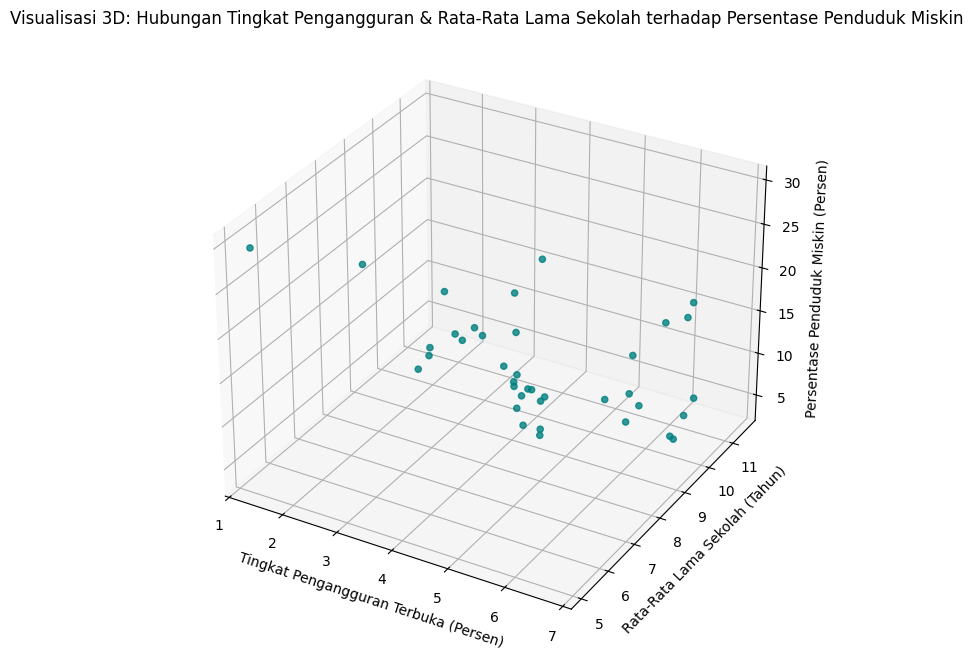

--------------------------------------------------


In [7]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

x1 = df['Tingkat Pengangguran Terbuka (Persen)']
x2 = df['Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas']

ax.scatter3D(x1, x2, y, color='teal', marker='o', alpha=0.8)

ax.set_title('Visualisasi 3D: Hubungan Tingkat Pengangguran & Rata-Rata Lama Sekolah terhadap Persentase Penduduk Miskin')
ax.set_xlabel('Tingkat Pengangguran Terbuka (Persen)')
ax.set_ylabel('Rata-Rata Lama Sekolah (Tahun)')
ax.set_zlabel('Persentase Penduduk Miskin (Persen)')

print("[INFO] Menampilkan grafik scatter plot 3D... Silakan tutup jendela grafik untuk melanjutkan proses perhitungan regresi.")
plt.show()
print("-" * 50)

In [8]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

koef_tpt = regr.coef_[0]
koef_rls = regr.coef_[1]
konstanta = regr.intercept_

In [9]:
y_pred = regr.predict(X)
r_square = r2_score(y, y_pred)

In [10]:
print("=================================================================")
print("             EVALUASI AKURASI MODEL (R-SQUARED)                  ")
print("=================================================================")
print(f"Nilai R-squared (R²)      : {r_square:.6f}")
print(f"Koefisien Determinasi (%) : {r_square * 100:.2f}%")
print("-----------------------------------------------------------------")
print(f"Sebesar {r_square * 100:.2f}% variasi tingkat 'Persentase Kemiskinan'")
print("di tingkat provinsi Indonesia dapat dijelaskan secara bersama-sama")
print("oleh variabel 'Tingkat Pengangguran Terbuka' (TPT) dan 'Rata-Rata Lama Sekolah' (RLS).")
print(f"Sedangkan sisanya yaitu sebesar {(1 - r_square) * 100:.2f}% dijelaskan oleh")
print("faktor-faktor lain di luar model regresi.")
print("=================================================================")

             EVALUASI AKURASI MODEL (R-SQUARED)                  
Nilai R-squared (R²)      : 0.298063
Koefisien Determinasi (%) : 29.81%
-----------------------------------------------------------------
Sebesar 29.81% variasi tingkat 'Persentase Kemiskinan'
di tingkat provinsi Indonesia dapat dijelaskan secara bersama-sama
oleh variabel 'Tingkat Pengangguran Terbuka' (TPT) dan 'Rata-Rata Lama Sekolah' (RLS).
Sedangkan sisanya yaitu sebesar 70.19% dijelaskan oleh
faktor-faktor lain di luar model regresi.


In [11]:
def validasi_arah_hubungan(koefisien, nama_variabel, arah_teoritis):
    if koefisien > 0:
        status = "POSITIF (+)"
        penjelasan = f"Setiap kenaikan {nama_variabel} akan cenderung meningkatkan persentase kemiskinan."
    else:
        status = "NEGATIF (-)"
        penjelasan = f"Setiap kenaikan {nama_variabel} akan cenderung menurunkan persentase kemiskinan."
    
    kesesuaian = "SESUAI TEORI" if status.split()[0].lower() == arah_teoritis.lower() else "ANOMALI"
    return status, penjelasan, kesesuaian

status_tpt, arti_tpt, cocok_tpt = validasi_arah_hubungan(koef_tpt, "Tingkat Pengangguran", "POSITIF")
status_rls, arti_rls, cocok_rls = validasi_arah_hubungan(koef_rls, "Rata-Rata Lama Sekolah", "NEGATIF")

In [12]:
print("=================================================================")
print("               PARAMETER MODEL REGRESI                           ")
print("=================================================================")
print(f"Konstanta (a)                  : {konstanta:.4f}")
print(f"Koefisien Pengangguran (b1)    : {koef_tpt:.4f} ({status_tpt} - {cocok_tpt})")
print(f"Koefisien Lama Sekolah (b2)    : {koef_rls:.4f} ({status_rls} - {cocok_rls})")
print("\nPersamaan Matematika Regresi Berganda:")
print(f"Y (Kemiskinan) = {konstanta:.4f} + ({koef_tpt:.4f} * TPT) + ({koef_rls:.4f} * RLS)")
print("\n--- INTERPRETASI VARIABEL ---")
print(f"1. Pengangguran: {arti_tpt}")
print(f"2. Lama Sekolah: {arti_rls}")
print("=================================================================")

               PARAMETER MODEL REGRESI                           
Konstanta (a)                  : 38.8728
Koefisien Pengangguran (b1)    : 0.0354 (POSITIF (+) - SESUAI TEORI)
Koefisien Lama Sekolah (b2)    : -3.0523 (NEGATIF (-) - SESUAI TEORI)

Persamaan Matematika Regresi Berganda:
Y (Kemiskinan) = 38.8728 + (0.0354 * TPT) + (-3.0523 * RLS)

--- INTERPRETASI VARIABEL ---
1. Pengangguran: Setiap kenaikan Tingkat Pengangguran akan cenderung meningkatkan persentase kemiskinan.
2. Lama Sekolah: Setiap kenaikan Rata-Rata Lama Sekolah akan cenderung menurunkan persentase kemiskinan.


In [13]:
def hitung_prediksi_aman(tpt, rls):
    prediksi_mentah = konstanta + (koef_tpt * tpt) + (koef_rls * rls)
    return prediksi_mentah

In [14]:
tpt_simulasi = 5.5
rls_simulasi = 10.2

prod_mentah = hitung_prediksi_aman(tpt_simulasi, rls_simulasi)

print("=================================================================")
print("             PREDIKSI PRESENTASE KEMISKINAN BARU                 ")
print("=================================================================")
print(f"Input Tingkat Pengangguran (X1)  : {tpt_simulasi} %")
print(f"Input Rata-rata Lama Sekolah (X2): {rls_simulasi} Tahun")
print(f"Estimasi Hasil Kemiskinan (Y)    : {prod_mentah:.2f} %")
print("=================================================================")

             PREDIKSI PRESENTASE KEMISKINAN BARU                 
Input Tingkat Pengangguran (X1)  : 5.5 %
Input Rata-rata Lama Sekolah (X2): 10.2 Tahun
Estimasi Hasil Kemiskinan (Y)    : 7.93 %


In [15]:
tpt_simulasi = 6
rls_simulasi = 8

prod_mentah = hitung_prediksi_aman(tpt_simulasi, rls_simulasi)

print("=================================================================")
print("             PREDIKSI PRESENTASE KEMISKINAN BARU                 ")
print("=================================================================")
print(f"Input Tingkat Pengangguran (X1)  : {tpt_simulasi} %")
print(f"Input Rata-rata Lama Sekolah (X2): {rls_simulasi} Tahun")
print(f"Estimasi Hasil Kemiskinan (Y)    : {prod_mentah:.2f} %")
print("=================================================================")

             PREDIKSI PRESENTASE KEMISKINAN BARU                 
Input Tingkat Pengangguran (X1)  : 6 %
Input Rata-rata Lama Sekolah (X2): 8 Tahun
Estimasi Hasil Kemiskinan (Y)    : 14.67 %


In [18]:
tpt_simulasi = 6
rls_simulasi = 9

prod_mentah = hitung_prediksi_aman(tpt_simulasi, rls_simulasi)

print("=================================================================")
print("             PREDIKSI PRESENTASE KEMISKINAN BARU                 ")
print("=================================================================")
print(f"Input Tingkat Pengangguran (X1)  : {tpt_simulasi} %")
print(f"Input Rata-rata Lama Sekolah (X2): {rls_simulasi} Tahun")
print(f"Estimasi Hasil Kemiskinan (Y)    : {prod_mentah:.2f} %")
print("=================================================================")

             PREDIKSI PRESENTASE KEMISKINAN BARU                 
Input Tingkat Pengangguran (X1)  : 6 %
Input Rata-rata Lama Sekolah (X2): 9 Tahun
Estimasi Hasil Kemiskinan (Y)    : 11.61 %
